# Benchmark Es4A vs Es4B (TrainStations)
Questo notebook compila i file C `es4A.c` e `es4B.c`, genera casi di test con $L = 1000000$ (1 milione) e confronta i tempi di esecuzione per validare le complessità teoriche $O(L + 2^N)$ e $O(M \log L)$.

In [3]:
import subprocess
import time
import random
import matplotlib.pyplot as plt

# Compilazione dei due eseguibili
print('Compilazione in corso...')
subprocess.run(['gcc', '-O2', 'es4A.c', '-o', 'es4A'])
subprocess.run(['gcc', '-O2', 'es4B.c', '-o', 'es4B'])
print('Compilazione completata.')

Compilazione in corso...


es4A.c: In function ‘main’:
es4A.c:90:5: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
   90 |     scanf("%d %d %d %d", &L, &N, &M, &controllo);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
es4A.c:103:9: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  103 |         scanf("%d", &s);
      |         ^~~~~~~~~~~~~~~
es4B.c: In function ‘main’:
es4B.c:131:5: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  131 |     scanf("%ld %d %d %ld", &L, &N, &M, &controllo);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
es4B.c:144:9: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  144 |         scanf("%ld", &s);
      |         ^~~~~~~~~~~~~~~~


Compilazione completata.


In [4]:
def generate_test_case(L, N, M, spacing_max=None):
    controllo = random.randint(1, L - 1)
    stations = {controllo}

    if spacing_max is None:
        while len(stations) < N:
            stations.add(random.randint(1, L - 1))
    else:
        # Costruisce una nuvola di stazioni attorno a controllo con gap variabili.
        positions = [controllo]
        left = controllo
        right = controllo

        while len(positions) < N:
            gap = random.randint(1, spacing_max)
            if random.random() < 0.5 and left > 1:
                left = max(1, left - gap)
                positions.append(left)
            elif right < L - 1:
                right = min(L - 1, right + gap)
                positions.append(right)
            else:
                positions.append(random.randint(1, L - 1))

        stations = set(positions)
        while len(stations) < N:
            stations.add(random.randint(1, L - 1))

    input_data = f"{L} {N} {M} {controllo}\n"
    for s in sorted(stations):
        input_data += f"{s}\n"
    return input_data


def run_test(executable, input_data, timeout_sec=3600):
    start = time.time()
    try:
        # Timeout applicato per prevenire il blocco della soluzione A (esponenziale)
        subprocess.run(['./' + executable], input=input_data.encode(), capture_output=True, timeout=timeout_sec)
        end = time.time()
        return end - start
    except subprocess.TimeoutExpired:
        return None  # Indica che ha sforato il limite di tempo

In [5]:
L = 1000000
# Per la soluzione A (esponenziale O(2^N)), N deve rimanere relativamente basso (es. <= 30)
# La soluzione B può scalare senza problemi, ma qui cerchiamo di graficare il punto di rottura di A.
N_values = range(2,33,3) 
M_ratio = 0.4  # Rimuoviamo il 40% delle stazioni

times_A = []
times_B = []
valid_N = []

print(f"Avvio test con L = {L}\n")
for N in N_values:
    M = int(N * M_ratio)
    input_data = generate_test_case(L, N, M)
    
    t_A = run_test('es4A', input_data, timeout_sec=3600)
    t_B = run_test('es4B', input_data, timeout_sec=3600)
    
    if t_A is not None:
        times_A.append(t_A)
        print(f"N={N:2d}, M={M:2d} -> es4A: {t_A:.4f}s")
    else:
        times_A.append(None)
        print(f"N={N:2d}, M={M:2d} -> es4A: TIMEOUT (> 5.0s)")
        
    if t_B is not None:
        times_B.append(t_B)
        print(f"            -> es4B: {t_B:.4f}s")
    else:
        times_B.append(None)
        print(f"            -> es4B: TIMEOUT")
        
    valid_N.append(N)
    print("-" * 40)

Avvio test con L = 1000000

N= 2, M= 0 -> es4A: 0.0176s
            -> es4B: 0.0255s
----------------------------------------
N= 5, M= 2 -> es4A: 0.0111s
            -> es4B: 0.0146s
----------------------------------------
N= 8, M= 3 -> es4A: 0.0083s
            -> es4B: 0.0430s
----------------------------------------
N=11, M= 4 -> es4A: 0.0164s
            -> es4B: 0.0175s
----------------------------------------
N=14, M= 5 -> es4A: 0.0345s
            -> es4B: 0.0435s
----------------------------------------
N=17, M= 6 -> es4A: 0.1072s
            -> es4B: 0.0131s
----------------------------------------
N=20, M= 8 -> es4A: 1.1528s
            -> es4B: 0.0112s
----------------------------------------


KeyboardInterrupt: 

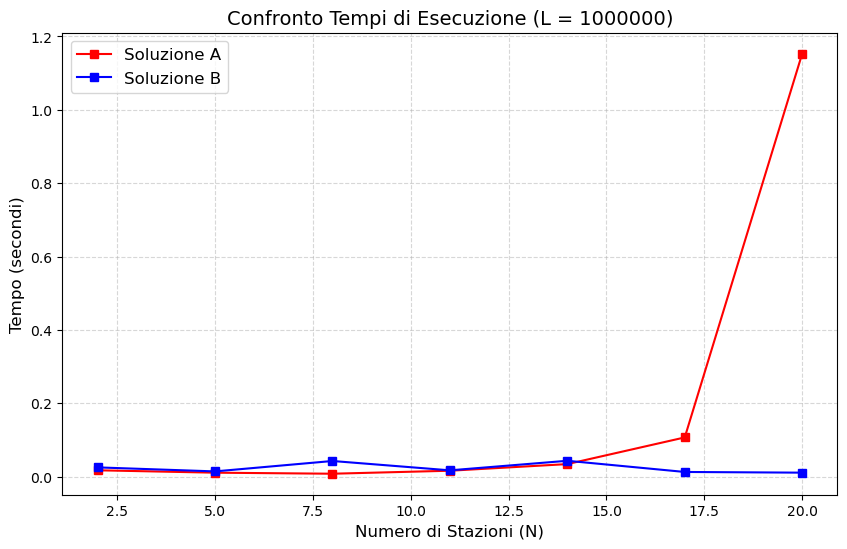

In [6]:
plt.figure(figsize=(10, 6))

# Filtra i valori validi per il plot della soluzione A
A_N = [n for n, t in zip(valid_N, times_A) if t is not None]
A_T = [t for t in times_A if t is not None]

plt.plot(A_N, A_T, label='Soluzione A', marker='s', color='red')
plt.plot(valid_N, times_B, label='Soluzione B', marker='s', color='blue')

plt.title(f'Confronto Tempi di Esecuzione (L = {L})', fontsize=14)
plt.xlabel('Numero di Stazioni (N)', fontsize=12)
plt.ylabel('Tempo (secondi)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [7]:
# Calcolo: esegue i test e raccoglie i risultati in una lista chiamata 'results'
import subprocess, time, random

# L parte oltre 10^10 e gli altri punti scendono gradualmente ma restano molto alti
L_values = [12_000_000_000, 11_000_000_000, 10_500_000_000, 10_000_000_000, 9_500_000_000, 9_000_000_000, 8_500_000_000, 8_000_000_000, 7_500_000_000, 7_000_000_000, 6_500_000_000, 6_000_000_000, 5_500_000_000, 5_000_000_000, 4_500_000_000, 4_000_000_000]
results = []

print('Compilazione finale di es4B in corso...')
subprocess.run(['gcc', '-O2', 'es4B.c', '-o', 'es4B'])

for L in L_values:
    # Un solo caso per ogni L, con N e M molto grandi ma proporzionati
    N = min(300_000, max(150_000, L // 80_000))
    M = max(1, N // 2)
    spacing_max = max(1_000, min(1_000_000, L // max(N, 1) // 4))
    input_data = generate_test_case(L, N, M, spacing_max=spacing_max)

    start = time.time()
    try:
        p = subprocess.run(['./es4B'], input=input_data.encode(), capture_output=True, timeout=3600)
        elapsed = time.time() - start
        results.append((L, elapsed))
        print(f'L={L:>12}, N={N:>7}, M={M:>7}, spacing_max={spacing_max:>8} -> {elapsed:.3f} s, returncode={p.returncode}')
    except subprocess.TimeoutExpired:
        print(f'L={L:>12}, N={N:>7}, M={M:>7}, spacing_max={spacing_max:>8} -> TIMEOUT after 3600 s')

Compilazione finale di es4B in corso...


es4B.c: In function ‘main’:
es4B.c:131:5: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  131 |     scanf("%ld %d %d %ld", &L, &N, &M, &controllo);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
es4B.c:144:9: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  144 |         scanf("%ld", &s);
      |         ^~~~~~~~~~~~~~~~


L= 12000000000, N= 150000, M=  75000, spacing_max=   20000 -> 22.543 s, returncode=0
L= 11000000000, N= 150000, M=  75000, spacing_max=   18333 -> 20.201 s, returncode=0
L= 10500000000, N= 150000, M=  75000, spacing_max=   17500 -> 19.253 s, returncode=0
L= 10000000000, N= 150000, M=  75000, spacing_max=   16666 -> 17.344 s, returncode=0
L=  9500000000, N= 150000, M=  75000, spacing_max=   15833 -> 16.918 s, returncode=0
L=  9000000000, N= 150000, M=  75000, spacing_max=   15000 -> 14.151 s, returncode=0
L=  8500000000, N= 150000, M=  75000, spacing_max=   14166 -> 13.688 s, returncode=0
L=  8000000000, N= 150000, M=  75000, spacing_max=   13333 -> 14.186 s, returncode=0
L=  7500000000, N= 150000, M=  75000, spacing_max=   12500 -> 13.187 s, returncode=0
L=  7000000000, N= 150000, M=  75000, spacing_max=   11666 -> 10.400 s, returncode=0
L=  6500000000, N= 150000, M=  75000, spacing_max=   10833 -> 9.447 s, returncode=0
L=  6000000000, N= 150000, M=  75000, spacing_max=   10000 -> 10.1

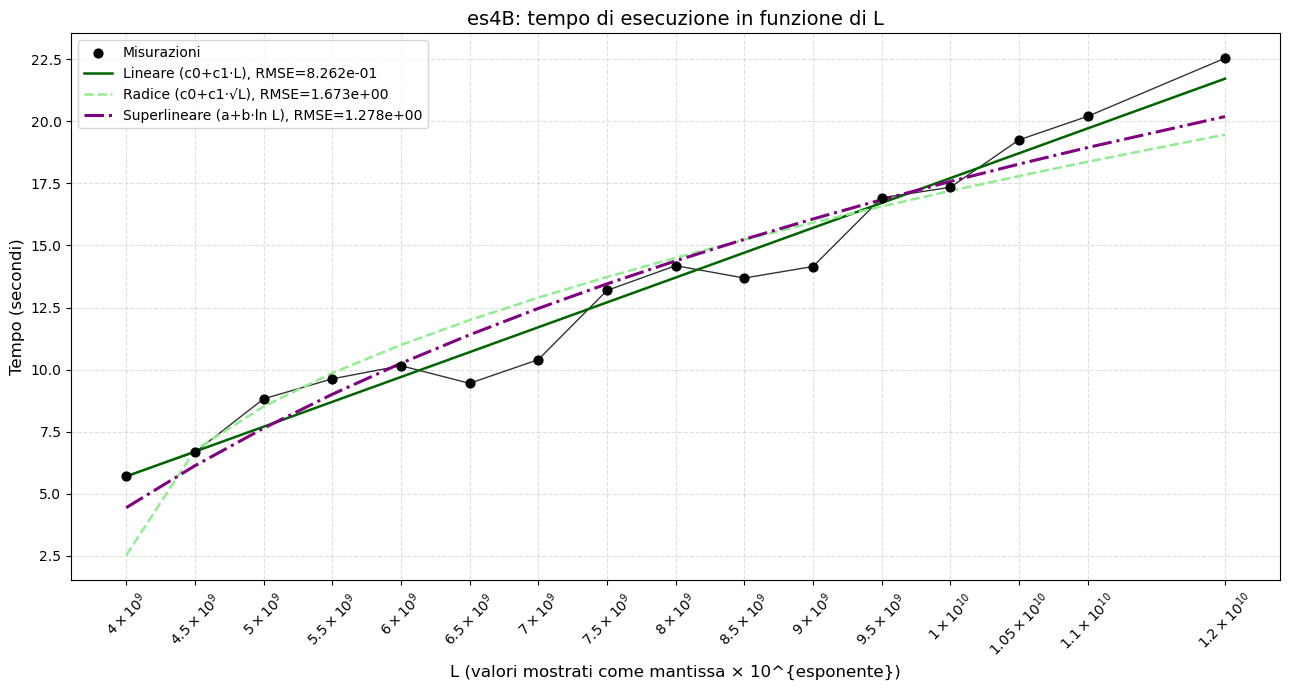

In [14]:
# Grafico: prende la lista 'results' e crea il plot separatamente
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.ticker import FuncFormatter

plot_L = np.array([l for l, t in results])
plot_times = np.array([t for _, t in results])

# Ordina per L crescente (richiesto dai modelli)
sort_idx = np.argsort(plot_L)
plot_L = plot_L[sort_idx]
plot_times = plot_times[sort_idx]

plt.figure(figsize=(13, 7))
# Dati misurati: nero (punti + linea) - aspetto da scienziato
plt.scatter(plot_L, plot_times, s=40, color='black', zorder=3, label='Misurazioni')
plt.plot(plot_L, plot_times, color='black', alpha=0.8, linewidth=1, zorder=2)

# FIT LEAST SQUARES PER TUTTI I MODELLI

# Lineare: c0 + c1*L
if plot_L.size > 0:
    coeffs_lin = np.polyfit(plot_L, plot_times, 1)
    c1_lin = coeffs_lin[0]
    c0_lin = coeffs_lin[1]
    lin_model = c0_lin + c1_lin * plot_L
    rmse_lin = np.sqrt(np.mean((plot_times - lin_model)**2))
else:
    lin_model = np.array([])
    rmse_lin = np.nan
    c0_lin = 0.0
    c1_lin = 0.0

# Curva chiara: fit a radice su L normalizzato, più naturale della vecchia parabola
if plot_L.size > 0:
    L_norm = (plot_L - plot_L.min()) / (plot_L.max() - plot_L.min())
    sqrt_feature = np.sqrt(L_norm)
    coeffs_root = np.polyfit(sqrt_feature, plot_times, 1)
    c1_root = coeffs_root[0]
    c0_root = coeffs_root[1]
    root_model = c0_root + c1_root * sqrt_feature
    rmse_root = np.sqrt(np.mean((plot_times - root_model)**2))
else:
    root_model = np.array([])
    rmse_root = np.nan
    c0_root = 0.0
    c1_root = 0.0

# Superlineare: a + b*ln(L)
logL = np.log(plot_L)
if plot_L.size > 0:
    coeffs_sup = np.polyfit(logL, plot_times, 1)
    b_opt = coeffs_sup[0]
    a_opt = coeffs_sup[1]
    super_model = a_opt + b_opt * logL
    rmse_super = np.sqrt(np.mean((plot_times - super_model)**2))
else:
    super_model = np.array([])
    rmse_super = np.nan
    a_opt = 0.0
    b_opt = 0.0

# Traccia i modelli con i colori richiesti, TUTTI con RMSE
plt.plot(plot_L, lin_model, color='darkgreen', linestyle='-', linewidth=1.8, label=f'Lineare (c0+c1·L), RMSE={rmse_lin:.3e}')
plt.plot(plot_L, root_model, color='#90ee90', linestyle='--', linewidth=1.8, label=f'Radice (c0+c1·√L), RMSE={rmse_root:.3e}')
plt.plot(plot_L, super_model, color='purple', linestyle='-.', linewidth=2.2, label=f'Superlineare (a+b·ln L), RMSE={rmse_super:.3e}')

# Formatta i tick sull'asse x in notazione scientifica dettagliata (mantissa × 10^{esponente})
ax = plt.gca()
ax.set_xticks(plot_L)
def sci_formatter(x, pos):
    if x == 0:
        return '0'
    s = f'{x:.2e}'
    mant, exp = s.split('e')
    mant_f = float(mant)
    exp_i = int(exp)
    mant_s = ('{:.0f}'.format(mant_f) if mant_f.is_integer() else ('{:.2f}'.format(mant_f)).rstrip('0').rstrip('.'))
    return rf'${mant_s}\times10^{{{exp_i}}}$'
ax.xaxis.set_major_formatter(FuncFormatter(sci_formatter))

# Grafica finale: etichette, legenda e stile da 'paper scientifico'
plt.title('es4B: tempo di esecuzione in funzione di L', fontsize=14)
plt.xlabel('L (valori mostrati come mantissa × 10^{esponente})', fontsize=12)
plt.ylabel('Tempo (secondi)', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()
